<a href="https://colab.research.google.com/github/gunamn06/GQT-internship-Projects/blob/main/(DL)Handwritten_digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow matplotlib numpy

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


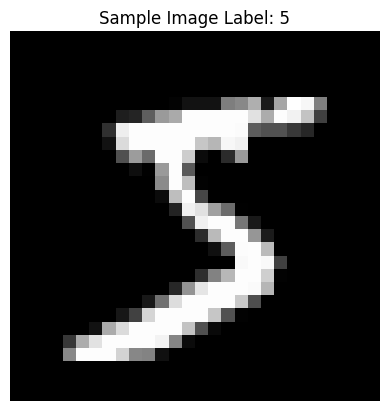

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9270 - loss: 0.2466
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9688 - loss: 0.1020
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9776 - loss: 0.0715
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9829 - loss: 0.0532
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9859 - loss: 0.0437
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9882 - loss: 0.0351
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9911 - loss: 0.0272
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9915 - loss: 0.0256
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9932 - loss: 0.0206
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9938 - loss: 0.0185
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.0979

 Test Accuracy: 0.9764999747276306
313/

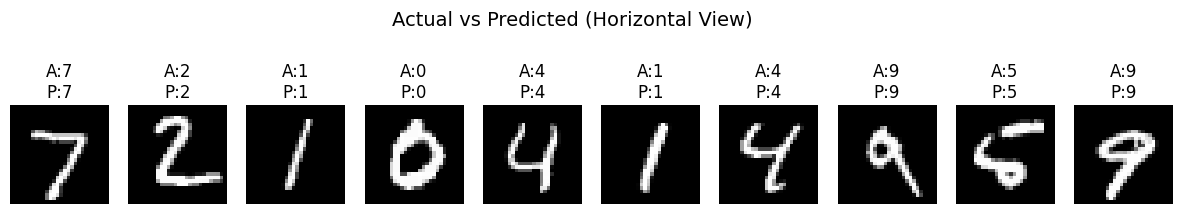

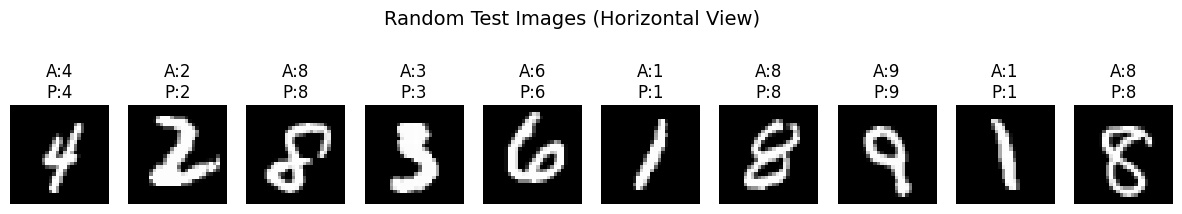

In [1]:
# =========================================
# HANDWRITTEN DIGIT RECOGNITION PROJECT
# =========================================

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import random

# -----------------------------------------
# STEP 1: Load Dataset (Inbuilt MNIST)
# -----------------------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# -----------------------------------------
# STEP 2: Explore Dataset
# -----------------------------------------
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Show one sample image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Sample Image Label: {y_train[0]}")
plt.axis('off')
plt.show()

# -----------------------------------------
# STEP 3: Preprocessing
# -----------------------------------------
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# -----------------------------------------
# STEP 4: Build Deep Learning Model
# -----------------------------------------
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),   # Convert 2D → 1D
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  # Output (0–9)
])

# -----------------------------------------
# STEP 5: Compile Model
# -----------------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------------------
# STEP 6: Train Model
# -----------------------------------------
model.fit(x_train, y_train, epochs=10)

# -----------------------------------------
# STEP 7: Evaluate Model
# -----------------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\n Test Accuracy:", test_acc)

# -----------------------------------------
# STEP 8: Predictions
# -----------------------------------------
predictions = model.predict(x_test)

# -----------------------------------------
# STEP 9: Display Images Horizontally
# -----------------------------------------

plt.figure(figsize=(15,3))  # horizontal layout

for i in range(10):   # first 10 images
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i], cmap='gray')

    actual = y_test[i]
    predicted = np.argmax(predictions[i])

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.suptitle("Actual vs Predicted (Horizontal View)", fontsize=14)
plt.show()

# -----------------------------------------
# STEP 10: Random Images (Better Demo)
# -----------------------------------------

plt.figure(figsize=(15,3))

for i in range(10):
    index = random.randint(0, len(x_test)-1)

    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[index], cmap='gray')

    actual = y_test[index]
    predicted = np.argmax(predictions[index])

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.suptitle("Random Test Images ", fontsize=14)
plt.show()